# Probabilistic Dimensionality Reduction with PPCA, FA, and GPFA

<a target="_blank" href="https://colab.research.google.com/github/ANDA-NI-2026/ANDA-Day3-Dimensionality-Reduction/blob/main/03_from_pca_to_gpfa/03_exercises.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

The previous notebook demonstrated how PCA can be useful for finding a few latent dimensions in neural recordings that explain most of the variance in the data. This notebook introduces three new methods, probabilistic PCA (PPCA), factor analysis (FA), and Gaussian process factor analysis (GPFA), that go one step further by introducing an explicit probabilistic model for how the data are generated. The notebook proceeds as follows:
- First, you are going to use some simple toy data to understand the differences in how PCA, PPCA, and FA represent the same data
- Next, you'll learn how PPCA and FA can be used as generative models to create new data for simulation and model validation
- Then, you are going to explore how PPCA and FA differ in how they deal with noise in the data
- Finally, you'll learn about GPFA and use it to analyze real electrophysiological recordings from the motor cortex of monkeys

## Setup

### Import Libraries

Run the cell below to import the libraries used in this notebook.

In [1]:
# When running in Colab, uncomment the line below to install the dependencies
!pip install neo elephant viziphant

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.1/458.1 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.7/697.7 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.0/104.0 kB 4.6 MB/s eta 0:00:00
  Created wheel for viziphant: filename=viziphant-0.4.0-py3-none-any.whl size=54621 sha256=6e8a01536d9a0c24b8b51e75625095918619a531effdc24fadbfb1109250ecd0
  Stored in directory: /root/.cache/pip/wheels/2d/92/12/65a82bd6b0fd15792a38760981e7aa7b9dde56f4a8eeda5df5
Successfully built viziphant


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

import quantities as pq
import neo
from elephant.gpfa import GPFA
from viziphant.rasterplot import rasterplot
from viziphant.gpfa import plot_dimensions_vs_time, plot_trajectories, plot_transform_matrix

%matplotlib inline

/usr/local/lib/python3.12/dist-packages/holoviews/util/parser.py:155: PyparsingDeprecationWarning: 'nestedExpr' deprecated - use 'nested_expr'
  plot_options_short = pp.nestedExpr('[',
/usr/local/lib/python3.12/dist-packages/holoviews/util/parser.py:158: PyparsingDeprecationWarning: 'setResultsName' deprecated - use 'set_results_name'
  ).setResultsName('plot_options')
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:477: PyparsingDeprecationWarning: 'ignoreExpr' argument is deprecated, use 'ignore_expr'
  return fn(*args, **kwargs)


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

### Download Data

Run the cell below to download the datasets used in this notebook.

In [3]:
import requests
from pathlib import Path

urls = ["https://uni-bonn.sciebo.de/s/izRNdytX5MB2Zm5/download",
        "https://uni-bonn.sciebo.de/s/pDZ7dBcsXGAEXoY/download"]
names = ["simulation_data.npy", "reach_data.npy"]

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

print("Downloading Data ...")
for url, name in zip(urls, names):
    fname = data_dir / name
    tmp_name = fname.with_suffix(".download")

    response = requests.get(f"{url}/download", timeout=60)
    response.raise_for_status()
    tmp_name.write_bytes(response.content)

    # Refuse to save server error pages or other non-NPY content as the dataset.
    with open(tmp_name, "rb") as file:
        magic = file.read(6)

    if magic != b"\x93NUMPY":
        tmp_name.unlink(missing_ok=True)
        raise ValueError(
            "Downloaded file is not a valid .npy file. The server may have returned an error page instead."
        )

    tmp_name.replace(fname)

print("Done!")

Done!


### Utility Functions

The cell below defines several utility functions. Call them as `utils.function()`.

In [4]:
def _as_1d_loading(w):
    w = np.asarray(w).squeeze()
    if w.ndim != 1:
        raise ValueError("Projection utilities expect a single loading vector of shape (D,) or (D, 1).")
    return w

def _plot_projection(X, z_hat, w):
    """
    Parameters
    ----------
    X : Data matrix of shape (N, 2) with N samples.
    z_hat: Vector of shape (N, ) with coordinates of the data points along the projection axis.
    w: Projection direction in observed space, shape (2,).
    """
    w = _as_1d_loading(w)
    z_hat = np.asarray(z_hat).squeeze()
    N = X.shape[0]
    mu = X.mean(axis=0)
    w_unit = w / np.linalg.norm(w)
    scale = 2 * np.max(np.std(X, axis=0))
    line_pts = mu[None, :] + np.array([-1, 1])[:, None] * scale * w_unit[None, :]
    X_proj = mu[None, :] + np.outer(z_hat, w)

    plt.plot(X[:, 0], X[:, 1], 'k.', ms=10, label='Data')
    plt.plot(mu[0], mu[1], 'g.', ms=16, label='Mean')
    plt.plot(line_pts[:, 0], line_pts[:, 1], 'k-', lw=1.5, label='Subspace')
    plt.plot(X_proj[:, 0], X_proj[:, 1], 'r.', ms=10, label='Projection')
    for i in range(N):
        plt.plot([X[i, 0], X_proj[i, 0]], [X[i, 1], X_proj[i, 1]], 'r-', lw=0.8)
    plt.axis("equal")
    plt.legend(fontsize=8)

def _pca(X, K):
    """
    Parameters
    ----------
    X : Data matrix of shape (N, D) with N samples and D observed dimensions.
    K : Number of principal components to keep.

    Returns
    -------
    W : Weights of shape (D, K)
    """
    mu = X.mean(axis=0)
    Xc = X - mu
    _, _, Vh = np.linalg.svd(Xc, full_matrices=False)
    W = Vh[:K].T

    return W

def _ppca(X, K, n_iters=300, seed=10):
    """
    Parameters
    ----------
    X : Data matrix of shape (N, D) with N samples and D observed dimensions.
    K : Number of latent dimensions/components.
    n_iters: Number of expectation-maximization iterations performed.
    seed: Random seed for reproducibility

    Returns
    -------
    W : Weights of shape (D, K)
    sigma2 : Estimated noise variance.
    lls: log-likelihood per iteration.
    """
    rng = np.random.default_rng(seed)
    N, D = X.shape
    mu = X.mean(axis=0)
    Xc = X - mu
    S  = (Xc.T @ Xc) / N
    W      = rng.standard_normal((D, K)) * 0.1
    sigma2 = 1.0
    lls = []
    for _ in range(n_iters):
        M     = W.T @ W + sigma2 * np.eye(K)
        M_inv = np.linalg.inv(M)
        Ez    = Xc @ W @ M_inv.T
        Ezz   = N * sigma2 * M_inv + Ez.T @ Ez
        W_new      = (Xc.T @ Ez) @ np.linalg.inv(Ezz)
        sigma2_new = (np.trace(S) - np.trace(W_new.T @ Xc.T @ Ez) / N) / D
        W      = W_new
        sigma2 = sigma2_new
        C        = W @ W.T + sigma2 * np.eye(D)
        _, logdet = np.linalg.slogdet(C)
        C_inv    = np.linalg.inv(C)
        ll       = -0.5 * N * (D * np.log(2 * np.pi) + logdet + np.trace(C_inv @ S))
        lls.append(ll)

    return W, sigma2, lls


def _fa(X, K, n_iters=300, seed=1):
    """
    Parameters
    ----------
    X : Data matrix of shape (N, D) with N samples and D observed dimensions.
    K : Number of latent dimensions/components to keep.
    n_iters: Number of expectation-maximization iterations performed.
    seed: Random seed for reproducibility

    Returns
    -------
    W : Weights of shape (D, K)
    Psi : Vector of shape (D,) with the noise variance for each observed dimension.
    lls: log-likelihood per iteration.
    """
    rng = np.random.default_rng(seed)
    N, D = X.shape
    mu = X.mean(axis=0)
    Xc = X - mu
    S  = (Xc.T @ Xc) / N
    W   = rng.standard_normal((D, K)) * 0.1
    Psi = np.ones(D)
    lls = []
    for _ in range(n_iters):
        # E-step
        Psi_inv = 1.0 / Psi                              # (D,)
        PsiW    = Psi_inv[:, None] * W                   # (D, K): Psi^{-1} W
        M       = W.T @ PsiW + np.eye(K)                 # (K, K)
        M_inv   = np.linalg.inv(M)
        Ez      = Xc @ PsiW @ M_inv.T                    # (N, K)
        Ezz     = N * M_inv + Ez.T @ Ez                  # (K, K): no sigma2 factor
        # M-step for W
        W_new   = (Xc.T @ Ez) @ np.linalg.inv(Ezz)      # (D, K)
        # M-step for Psi
        EzXc    = (Ez.T @ Xc) / N                        # (K, D)
        Psi_new = np.diag(S) - np.sum(W_new * EzXc.T, axis=1)  # (D,)
        Psi_new = np.maximum(Psi_new, 1e-6)
        W   = W_new
        Psi = Psi_new
        # Log-likelihood
        C         = W @ W.T + np.diag(Psi)
        _, logdet = np.linalg.slogdet(C)
        C_inv     = np.linalg.inv(C)
        ll        = -0.5 * N * (D * np.log(2 * np.pi) + logdet + np.trace(C_inv @ S))
        lls.append(ll)
    return W, Psi, lls

def _project_pca(X, w):
    w = _as_1d_loading(w)
    X_c = X - X.mean(axis=0)
    z = X_c @ w
    return z

def _project_ppca(X, w, sigma2):
    w = _as_1d_loading(w)
    X_c = X - X.mean(axis=0)
    M = w.T @ w + sigma2
    z = (X_c @ w) / M
    return z

def _project_fa(X, w, Psi):
    w = _as_1d_loading(w)
    X_c = X - X.mean(axis=0)
    Psi_inv = 1.0 / Psi
    Psiw = Psi_inv * w
    M_fa = w.T @ Psiw + 1
    z = (X_c @ Psiw) / M_fa
    return z

def _compare_covariance(X, W, noise_variance):

    X_c = X - X .mean(axis=0)
    cov_sample = (X_c.T @ X_c) / len(X)
    if np.ndim(noise_variance) == 0: # sigma2
        noise_cov = noise_variance * np.eye(X.shape[1])
    else: # Psi
        noise_cov = np.diag(noise_variance)
    cov_model   = W @ W.T + noise_cov

    diff = cov_sample - cov_model

    im = plt.imshow(diff)
    plt.colorbar(im, label='Covariance difference')
    plt.xticks(range(X.shape[1]), [f'X {i+1}' for i in range(X.shape[1])])
    plt.yticks(range(X.shape[1]), [f'X {i+1}' for i in range(X.shape[1])])

    for i in range(X.shape[1]):
        for j in range(X.shape[1]):
            plt.text(j, i, f'{diff[i, j]:.2e}', ha='center', va='center', color='white')

class utils:
    as_1d_loading = _as_1d_loading
    plot_projection = _plot_projection
    pca = _pca
    ppca = _ppca
    fa = _fa
    project_pca = _project_pca
    project_ppca = _project_ppca
    project_fa = _project_fa
    compare_covariance = _compare_covariance

## Comparing PCA to Probabilistic PCA and Factor Analysis

PCA finds low-dimensional structure by looking for directions that explain as much variance as possible, but it does not include an explicit noise model. Probabilistic PCA (**PPCA**) and factor analysis (**FA**) address this by modeling each observation as a low-dimensional latent variable projected into observed space plus noise:

$$\mathbf{x}_n = W \mathbf{z}_n + \boldsymbol{\mu} + \boldsymbol{\epsilon}_n$$

Here, $x_n$ is the observed spike count in trial $n$, $z_n$ is a low-dimensional **latent variable** that captures shared structure, $W$ is the **loading matrix**, and $\epsilon_n$ captures private variability that is not explained by the latent state.

The key difference between these methods lies in the noise model. PPCA assumes **isotropic** noise, meaning every observed dimension has the same private noise variance. FA instead allows the noise variance to differ across observed dimensions.

In this section, you will compare PCA, PPCA, and FA on a small simulated dataset with 8 two-dimensional data points and visualize how each model represents the data.

### Code Reference

| Code | Description |
| --- | --- |
| `W_ppca, sigma2, lls_ppca = utils.ppca(X, K=1, n_iters=100)` |  Compute PPCA on `X` with `K=1` components for `100` iterations and return the weights `W_ppca`, the noise variance `sigma2` and the log-likelihood for each iteration `lls_ppca` |
| `W_fa, Psi, lls_fa = utils.fa(X, K=1, n_iters=100)` | Compute FA on `X` with `K=1` components for `100` iterations and return the weights `W_fa`, the noise variance `Psi` and the log-likelihood for each iteration `lls_fa` |
| `z_ppca = utils.project_ppca(X, W_ppca, sigma2)` | Project `X` onto one PPCA dimension to obtain the coordinates along the latent dimension `z_ppca` |
| `z_fa = utils.project_fa(X, W_fa, Psi)` | Project `X` onto one FA dimension to obtain the coordinates along the latent dimension `z_fa` |
| `utils.plot_projection(X, z, w_pca)` | Plot the original data `X` and the projection onto the latent dimension `z` |
| `plt.plot(data, color="red", linestyle='--')` | Plot `data` as a red dashed line |

### Exercises


Please fill in the blank cells with working code, according to each exercise below.

Note: **"Example"** exercises already have the solutions, and will help show how the code is used for the exercises that follow.


Run the cell below to load the data `X` and visualize it in a scatterplot.

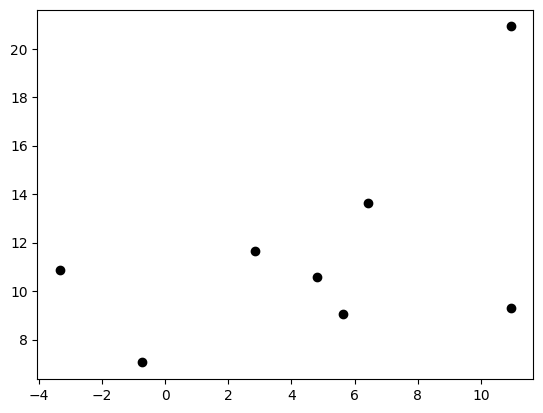

In [5]:
X = np.load('data/simulation_data.npy')
plt.scatter(X[:, 0], X[:, 1], color='black');

**Example**: Compute PPCA with `K=1` components on the data `X` for `n_iters=5` iterations to get the weights `W_ppca`, the noise variance `sigma2` and the log-likelihood `lls_ppca`. Plot the log-likelihood to check if the model converged.

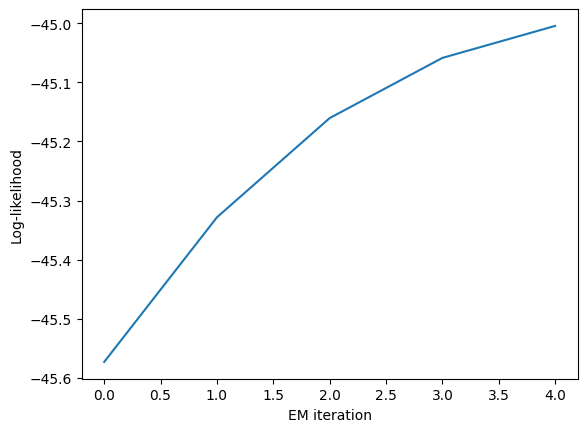

In [6]:
W_ppca, sigma2, lls_ppca = utils.ppca(X, K=1, n_iters=5)

plt.plot(lls_ppca)
plt.xlabel('EM iteration')
plt.ylabel('Log-likelihood');

**Exercise**: In the prior example, the log-likelihood did not plateau, indicating that the model did not converge. Increase the number of iterations so that the model converges.

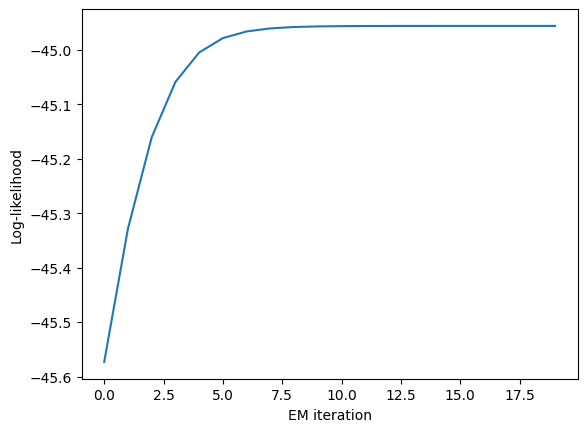

In [7]:
W_ppca, sigma2, lls_ppca = utils.ppca(X, K=1, n_iters=20)

plt.plot(lls_ppca)
plt.xlabel('EM iteration')
plt.ylabel('Log-likelihood');

**Exercise**: Compute FA with `K=1` components on the data `X` to get the weights `W_fa`, the noise variance `Psi` and the log-likelihood `lls_fa`. Plot the log-likelihood to check if the model converged.

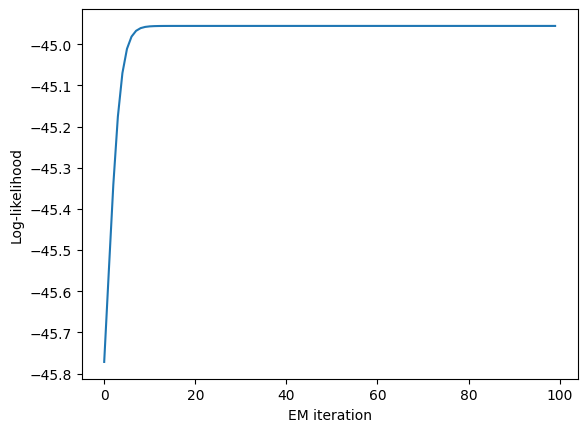

In [8]:
W_fa, Psi, lls_fa = utils.fa(X, K=1, n_iters=100)

plt.plot(lls_fa)
plt.xlabel('EM iteration')
plt.ylabel('Log-likelihood');

Now that you fitted the PPCA and FA models we are going to visualize their outputs and compare them to regular PCA. The cell below computes PCA with `K=1` component to get the weights `W_pca`.

In [9]:
W_pca = utils.pca(X, K=1)

**Example**: Project the data `X` onto the first PCA direction to obtain the latent coordinates `Z_pca`. Then plot the projection of the data onto this latent dimension.

In the plot, the black line shows the first PCA direction, the black dots are the original data points, and the red dots are their projections onto that direction. The further a red dot lies from the mean along the black line, the larger that data point's latent coordinate, or PCA score, on the component.

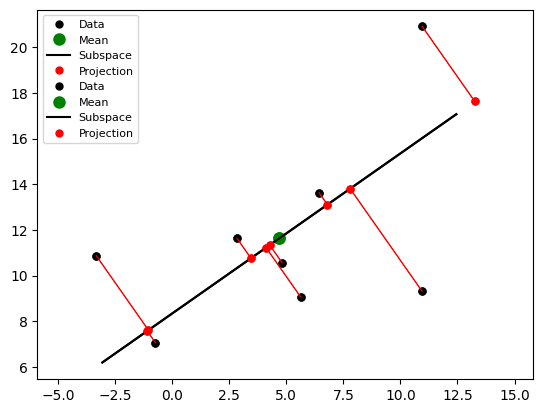

In [13]:
Z_pca = utils.project_pca(X, W_pca)
utils.plot_projection(X, Z_pca, W_pca)

utils.plot_projection(X, Z_pca, W_pca)


**Exercise**: Project the data `X` onto the first PPCA direction to obtain the latent coordinates `Z_ppca`. Then plot the projection of the data onto this latent dimension (**Hint**: `utils.project_ppca` takes 3 inputs: the data `X`, the PPCA weights `W_ppca` and the noise variance `sigma2`).


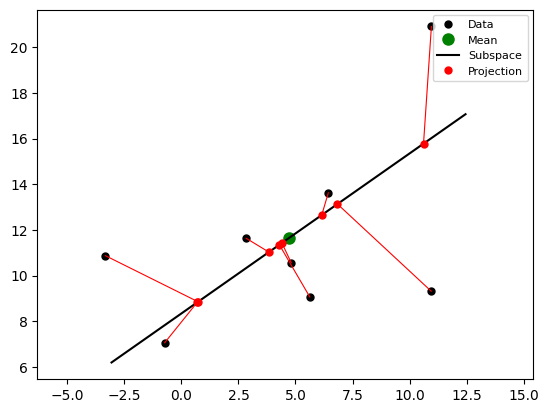

In [14]:
W_ppca, sigma2, lls_ppca = utils.ppca(X, K=1, n_iters=20)
z_ppca = utils.project_ppca(X, W_ppca, sigma2)

utils.plot_projection(X, z_ppca, W_ppca)

Note how the red connection lines are NOT orthogonal to the subspace in PPCA. Each point is pulled towards the subspace, but the pull is not purely perpendicular —
it accounts for uncertainty in the latent variable (the Bayesian shrinkage effect).

**Exercise**: Project the data `X` onto the first FA direction to obtain the latent coordinates `Z_fa`. Then plot the projection of the data onto this latent dimension.

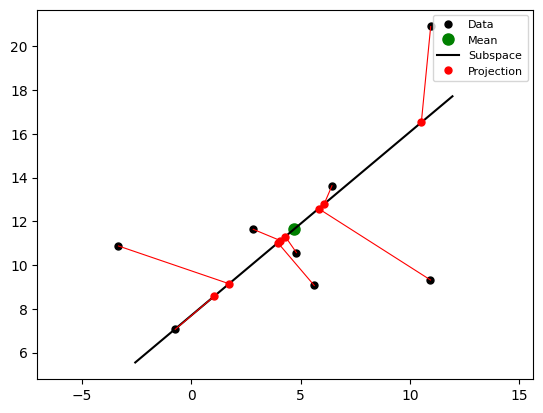

In [15]:
z_fa = utils.project_fa(X, W_fa, Psi)
utils.plot_projection(X, z_fa, W_fa)

**Exercise**: The projection plots for FA and PPCA look very similar. We can plot the latent dimensions together so we can better compare them. The code below plots the first direction for PCA. Add the first dimensions for PPCA and FA to the same plot and compare them (**Hint**: use different `color` and `linestyle` to differentiate overlaying lines).

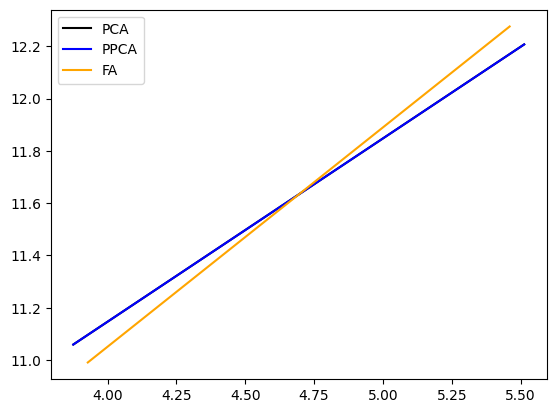

In [20]:
mu = X.mean(axis=0)

w = W_pca[:,0] / np.linalg.norm(W_pca[:,0]) # scaled 1st PCA direction
line  = mu + np.array([-w, w]) # line coordinates

w1 = W_ppca[:,0] / np.linalg.norm(W_ppca[:,0]) # scaled 1st PCA direction
line_ppca  = mu + np.array([-w1, w1]) # line coordinates

w2 = W_fa[:,0] / np.linalg.norm(W_fa[:,0]) # scaled 1st PCA direction
line_fa  = mu + np.array([-w2, w2]) # line coordinates

plt.plot(line[:, 0],  line[:, 1],  color='black', linestyle='-', label='PCA')
plt.plot(line_ppca[:, 0],  line_ppca[:, 1],  color='b', linestyle='-', label='PPCA')
plt.plot(line_fa[:, 0],  line_fa[:, 1],  color='orange', linestyle='-', label='FA')
plt.legend();

## Using PPCA and FA as Generative Models

PPCA and FA are generative models, so once we estimate their parameters we can sample new latent variables and noise to generate synthetic observations.
To generate data, we sample latent variables from a standard normal distribution:
$$\mathbf{z}_n \sim \mathcal{N}(0, I_K)$$

where $I_K$ is the $K \times K$ identity matrix. We also sample noise using the model's estimated variance $\sigma^2$ (for PPCA) or $\Psi$ (for FA):
$$
\text{PPCA: } \boldsymbol{\epsilon}_n \sim \mathcal{N}(0, \sigma^2 I_D)
\qquad
\text{FA: } \boldsymbol{\epsilon}_n \sim \mathcal{N}(0, \Psi)
$$

Using the estimated weights, we then map the latent variables into observed space and add the mean offset and noise:
$$
\mathbf{x}^{\mathrm{gen}}_n
= W\mathbf{z}_n + \boldsymbol{\mu} + \boldsymbol{\epsilon}_n
$$

In this section, you will generate new data from the PPCA and FA models and compare the samples to the original dataset. For sampling latent variables and noise, you will use NumPy's random number generator (`np.random.default_rng`) with a fixed seed for reproducibility.

### Code Reference

| Code | Description |
| --- | --- |
| `rng = np.random.default_rng(1)` | Create a random number generator with a fixed seed |
| `rng.normal(mean, std, size=(10, 2))` | Sample data of shape `(10, 2)` from a normal distribution with the given mean and standard deviation |
| `X_gen = Z @ W.T + mu + noise` | Generate observed data from latent variables, mean, and noise |

### Exercise

First, we compute the PPCA to obtain the model weights `W_ppca` and estimated noise variance `sigma2`. We also need the mean of the data `mu`. From these parameters, we can generate new data.

In [ ]:
W_ppca, sigma2, _ = utils.ppca(X, K=1)
mu = X.mean(axis=0)

**Example**: Sample latent variables `Z` of shape `(10, 1)` from a standard normal distribution and `noise` of shape `(10, 2)` using the estimated standard deviation. Print the mean of both.

In [ ]:
rng = np.random.default_rng(1)
Z = rng.normal(0, 1, size=(10, 1))
noise = rng.normal(0, np.sqrt(sigma2), size=(10, 2))

Z.mean(), noise.mean()

(np.float64(0.22490823808597696), np.float64(-0.6338291973863355))

**Exercise**: Draw 100 samples for `Z` and `noise` and print their mean again. The larger the sample, the closer the mean should be to 0.

**Exercise**: Complete the code below that generates the new data `X_gen` by adding the mean and noise to the projected latent variables and plot the generated data together with the original data.

In [ ]:
X_gen = Z @ W_ppca.T +  # add mu and noise

plt.scatter(X[:, 0], X[:, 1], label='Original')
plt.scatter(X_gen[:, 0], X_gen[:, 1], label='Generated')
plt.legend();

**Exercise**: The code below recomputes PPCA but with `K=2` components. Generate 100 new data points using the estimated weights `W_ppca` and noise `sigma2` (**Hint**: adjust the dimensions of the latent variable `Z` so they match `W_ppca`).

In [ ]:
W_ppca, sigma2, _ = utils.ppca(X, K=2)

**Exercise**: Compute FA with `K=1` components on `X` and generate 100 new data points from the estimated parameters (**Hint**: generating new data from FA works exactly the same as for PPCA, you just use the noise term `Psi` instead of `sigma2`).

## Examining the Noise Models of PPCA and FA

PPCA and FA differ in how they model noise. PPCA uses a single shared variance term $\sigma^2$:

$$\boldsymbol{\epsilon}_n \sim \mathcal{N}(0, \sigma^2 I_D)$$

This means the noise is **isotropic**, with the same variance along every observed dimension. FA instead models noise with a diagonal covariance:

$$
\boldsymbol{\epsilon}_n \sim \mathcal{N}(0, \Psi)
$$

where $\Psi = \operatorname{diag}(\psi_1, \ldots, \psi_D)$ allows each observed dimension to have its own noise variance. To see why this matters, we will add extra noise to one observed dimension and compare how well PPCA and FA recover the covariance structure of the data. We will also inspect the estimated weights and noise terms directly.

In this section, we will work with data generated from PPCA in the previous section, which gives us more samples and therefore more stable covariance estimates. A new utility function will compare the data covariance matrix to the model covariance matrix.

### Code Reference

| Description | Code |
| --- | --- |
| `W_ppca, sigma2, _ = utils.ppca(X, K=1)` | Compute PPCA with `K=1` parameters |
| `W_fa, Psi, _ = utils.fa(X, K=1)` | Compute FA `K=1` parameters |
| `utils.compare_covariance(X, W, noise_variance)` | Compare data and model covariance matrices (`noise_variance` is either $\sigma^2$ or $\Psi$)

### Exercises

First, we compute PPCA with `K=2` components and then generate 1000 new samples from the model. This gives us a lot of data to work with.

In [ ]:
W_ppca, sigma2, _ = utils.ppca(X, K=2)
mu = X.mean(axis=0)

rng = np.random.default_rng(1)
Z = rng.normal(0, 1, size=(1000, 2))
noise = rng.normal(0, np.sqrt(sigma2), size=(1000, 2))

X_gen = Z @ W_ppca.T + mu + noise
X_gen.shape

(1000, 2)

**Example**: Compute PPCA with `K=1` components and then compare the data and model covariance matrices. Under isotropic noise, PPCA should approximate the covariance matrix well.

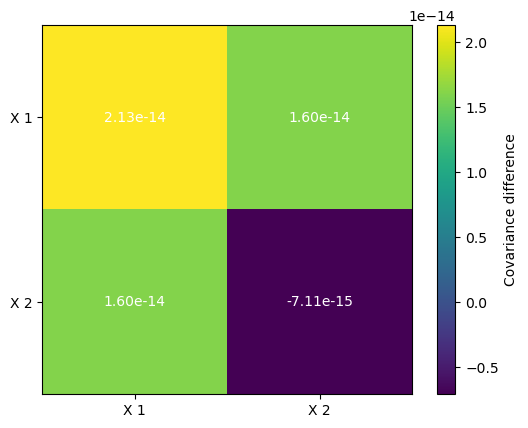

In [ ]:
W_ppca, sigma2, _ = utils.ppca(X_gen, K=1)
utils.compare_covariance(X_gen, W_ppca, sigma2)


**Example**: Print the estimated noise variance and the weights.

In [ ]:
print("Noise variance: ", sigma2)
print("Weights: \n", W_ppca)

Noise variance:  9.098796307732007
Weights: 
 [[-3.66881483]
 [-2.42184076]]


Now we add noise to the first dimension of our data. Let's see how this affects the results from PPCA!

In [ ]:
rng = np.random.default_rng(1)
X_noisy = X_gen.copy()
X_noisy[:, 0] += rng.normal(0, 20, size=len(X_noisy))

**Exercise**: Compute PPCA on `X_noisy` and compare the covariance matrices. How does the difference between the matrices compare to the previous example (**Hint**: a positive value indicates that the model underestimates the variance/covariance)?

**Exercise**: Even though the non-isotropic noise increased the error, the absolute difference was still very small. This is because PPCA can absorb the added non-isotropic variance into the model weights. To check this, print the estimated noise and model weights. If the weights are absorbing the added variance we should see an increase in the first dimension where noise was added.

**Exercise**: Now compute FA on `X_noisy` and compare the covariance matrices. How does the result compare to PPCA?

**Exercise**: Print the estimated weights and noise variance $\Psi$. The first element of $\Psi$ should reflect the increased noise in the dimension where noise was added.

## From FA to GPFA: Smooth Neural Trajectories

FA explains each observation with a low-dimensional latent variable, but it treats observations as independent. Neural activity during a trial has temporal structure: activity in neighboring time bins should usually be related. Gaussian Process Factor Analysis (**GPFA**) extends FA by placing a Gaussian process prior on the latent state, so the latent variables form smooth trajectories through time.

The observation model is still factor-analysis-like:

$$
x_{d,t} = (W z_t)_d + \epsilon_{d,t},
\qquad
\epsilon_{d,t} \sim \mathcal{N}(0, \psi_d)
$$

The new part is that each latent dimension evolves smoothly over time according to a Gaussian process. This lets GPFA estimate single-trial neural trajectories rather than one static latent coordinate per trial.

In this section, we use a reach-to-grasp dataset with four behavioral conditions: precision grip or side grip, each at low or high force. The goal is not to write data-wrangling code from scratch, but to use GPFA outputs to ask conceptual questions: which latent dimensions separate conditions, whether trajectories differ in shape or amplitude, and how individual neurons contribute to condition-separating latent dimensions.

### Code Reference

| Code | Description |
| --- | --- |
| `GPFA(bin_size=20 * pq.ms, x_dim=4)` | Create a GPFA model with 4 latent dimensions |
| `gpfa.fit_transform(spiketrains)` | Fit GPFA and return latent trajectories |
| `plot_dimensions_vs_time(...)` | Plot latent coordinates as time courses |
| `plot_trajectories(..., dimensions=[0, 2])` | Plot neural trajectories in selected latent dimensions |
| `plot_transform_matrix(gpfa.params_estimated['Corth'])` | Visualize how neurons load onto the plotted latent dimensions |
| `gpfa.params_estimated['Corth'][:, latent_dim]` | Get neuron weights for one plotted latent dimension |

### Exercises


First, we load the data and print the number of neurons, trials as well as the different conditions. There are two experimental variables that are being varied: **grip type** (PG: precision grip, SG: side grip) and **grip force** (LF: low force, HF: high force).

In [ ]:
data = np.load('data/reach_data.npy', allow_pickle=True).item()

spiketrains_raw = data['spiketrains']   # object array: trials x neurons
conditions = data['conditions']         # condition label per trial, e.g. 'PGLF'
T_STOP = float(data['t_stop'])          # trial window in ms

n_trials, n_neurons = spiketrains_raw.shape

print(f'Trials: {n_trials}   Neurons: {n_neurons}   Window: {T_STOP:.0f} ms')
for name in np.unique(conditions):
    print(f'{name}: {(conditions == name).sum()} trials')

Trials: 142   Neurons: 105   Window: 500 ms
PGHF: 36 trials
PGLF: 35 trials
SGHF: 36 trials
SGLF: 35 trials


We can also take a look at the average firing rates of the individual neurons. Some neurons fire much more than others, but high firing rate alone does not tell us which neurons contribute to differences between experimental conditions. Later, we will use the GPFA loading matrix to connect condition-separating latent dimensions back to individual neurons.

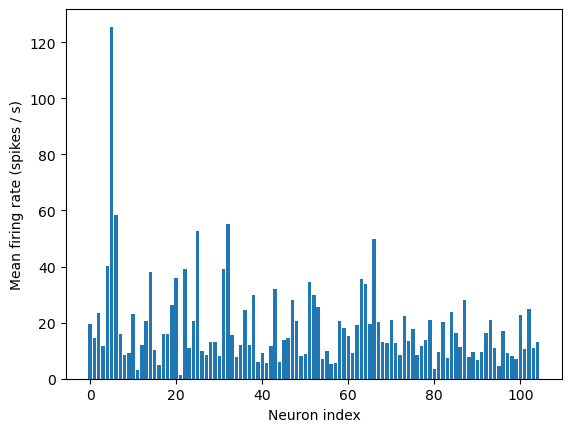

In [ ]:
BIN_MS = 20.0
bin_edges = np.arange(0, T_STOP + BIN_MS, BIN_MS)
n_bins = len(bin_edges) - 1

counts = np.zeros((n_trials, n_neurons, n_bins))

for trial in range(n_trials):
    for neuron in range(n_neurons):
        times = spiketrains_raw[trial, neuron]
        if times is not None:
            counts[trial, neuron], _ = np.histogram(times, bins=bin_edges)

mean_rate = counts.mean(axis=(0, 2)) * (1000 / BIN_MS)

plt.bar(np.arange(n_neurons), mean_rate)
plt.xlabel('Neuron index')
plt.ylabel('Mean firing rate (spikes / s)');

Finally, we need to prepare the data for analysis. The GPFA implementation expects the data to be stored in `neo.SpikeTrain` objects, so the cell below prepares a list of `spiketrains` and creates a raster plot for the first trial. It also creates the `trial_grouping_dict`, which stores which trials belong to which condition. Now we are ready to apply GPFA.

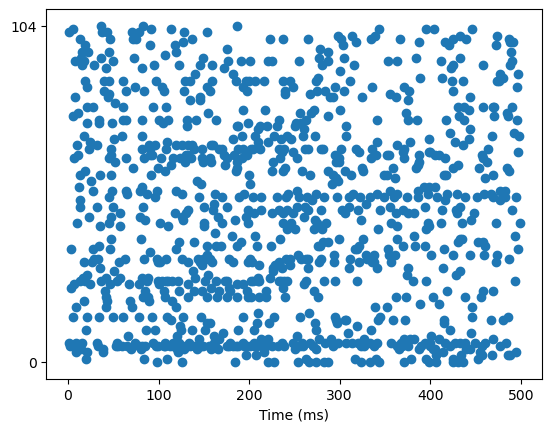

In [ ]:
spiketrains = []
for trial in range(n_trials):
    trial_spiketrains = []
    for neuron in range(n_neurons):
        times = spiketrains_raw[trial, neuron]
        times = times if (times is not None and len(times) > 0) else np.array([])
        trial_spiketrains.append(neo.SpikeTrain(times * pq.ms, t_stop=T_STOP * pq.ms))
    spiketrains.append(trial_spiketrains)

trial_grouping_dict = defaultdict(list)
for trial_idx, name in enumerate(conditions):
    trial_grouping_dict[name].append(trial_idx)

rasterplot(spiketrains[0]);

**Example**: Fit a 4-dimensional GPFA model to `spiketrains` with a 50 ms `bin_size`.

In [ ]:
np.random.seed(1)
gpfa = GPFA(bin_size=50 * pq.ms, x_dim=4)
returned = gpfa.fit_transform(spiketrains)

Initializing parameters using factor analysis...

Fitting GPFA model...


**Example**: Plot the GPFA components. The curves show how the latent coordinates for each component change across time. Each subplot's title indicates how much variance in the shared activity is explained by that component.

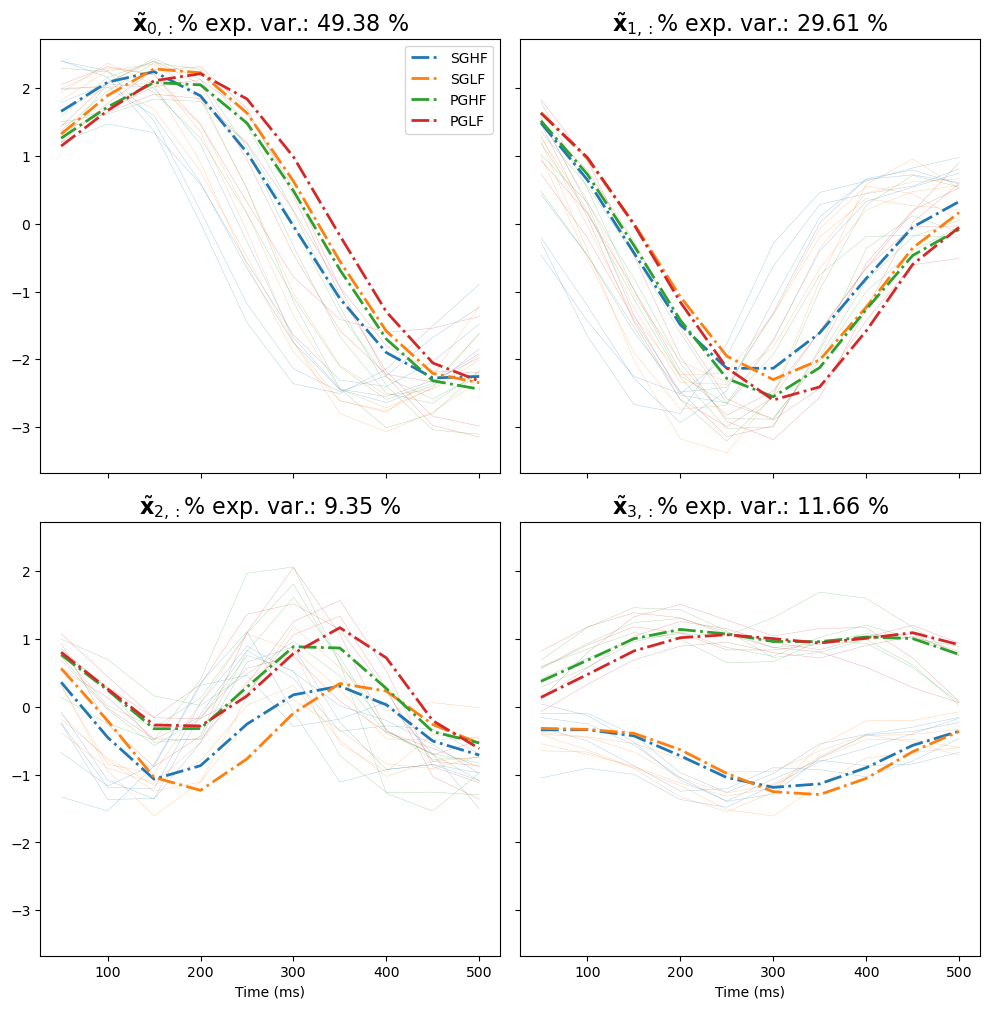

In [ ]:
plot_dimensions_vs_time(
    returned,
    gpfa,
    trial_grouping_dict=trial_grouping_dict,
    plot_group_averages=True);

**Exercise**: The 50 ms time bins in the previous example are fairly coarse. Reduce the bin size to 20 ms, fit GPFA again, and plot the latent dimensions across time.

**Exercise**: Fit GPFA again but increase the number of dimensions to 8. This will take longer to compute. Plot the latent coordinates across time and compare how much shared variance is captured by the additional dimensions.

**Example**: Plot condition-averaged neural trajectories in two latent dimensions. A trajectory plot shows how the population state moves through latent space during the trial.

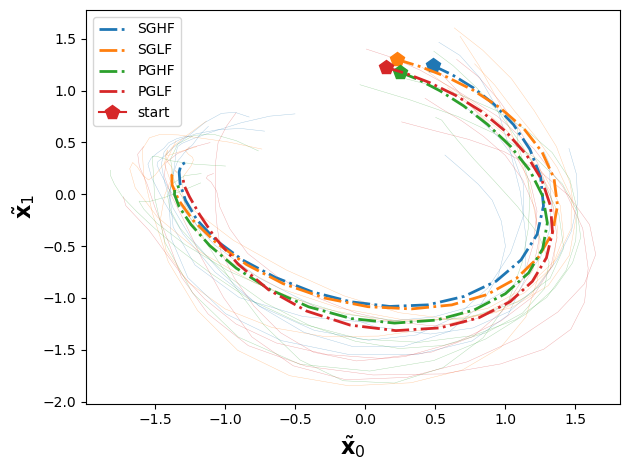

In [ ]:
plot_trajectories(
    returned, gpfa,
    dimensions=[0, 1],
    trial_grouping_dict=trial_grouping_dict,
    plot_group_averages=True);

**Exercise**: In the previous example, we could not see a difference between experimental conditions in the selected dimensions. Look at the plot of the individual components and identify two that differ across conditions then plot the trajectories for those dimensions.

**Exercise**: Add a third dimension to the trajectory plot. Does the neural activity encode grip type (PG/SG) or grip force (LF/HF)?

The loading matrix shows how strongly each neuron contributes to each plotted latent dimension. This is useful after identifying a latent dimension that separates conditions: we can select neurons with large positive or negative weights on that dimension and inspect their firing rates across conditions.

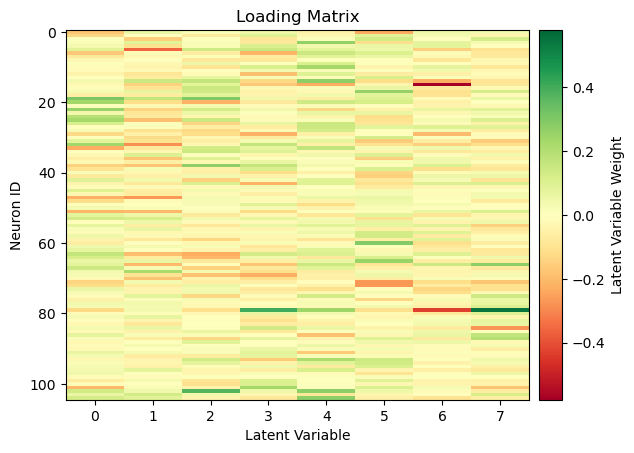

In [ ]:
plot_transform_matrix(gpfa.params_estimated['Corth']);

**Exercise**: The code below selects one `latent_dim`, finds the `n_top` neurons with the largest absolute weights along this dimension, and plots their average PSTHs. Vary `latent_dim` and `n_top` to look for neurons whose activity differs between experimental conditions.

Selected neurons: [ 79 101]
Weights: [0.40599052 0.23340289]


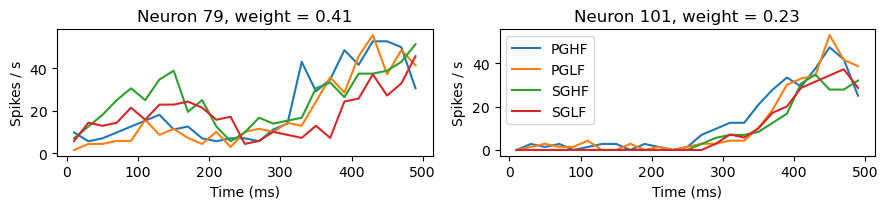

In [ ]:
latent_dim = 3
n_top = 2

Corth = gpfa.params_estimated['Corth']
weights = Corth[:, latent_dim]
top_neurons = np.argsort(np.abs(weights))[-n_top:][::-1]

print('Selected neurons:', top_neurons)
print('Weights:', weights[top_neurons])

time = bin_edges[:-1] + BIN_MS / 2
rate_scale = 1000 / BIN_MS
n_cols = 2
n_rows = int(np.ceil(n_top / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, 2.2 * n_rows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, neuron in zip(axes, top_neurons):
    for condition in np.unique(conditions):
        trial_idx = conditions == condition
        ax.plot(time, counts[trial_idx, neuron, :].mean(axis=0) * rate_scale, label=condition)

    ax.set_title(f'Neuron {neuron}, weight = {weights[neuron]:.2f}')
    ax.set_ylabel('Spikes / s')
    ax.set_xlabel('Time (ms)')

axes[1].legend()
plt.tight_layout()

### Reflection: The PCA → PPCA → FA → GPFA Ladder

| Method | Noise model | Temporal structure | Dataset |
| --- | --- | --- | --- |
| **PCA** | no explicit noise model | none (static trials) | PMd spike counts |
| **PPCA** | explicit isotropic ($\sigma^2 I$) | none | Xsim (2D toy) |
| **FA** | explicit diagonal ($\Psi$) | none | Xsim (2D toy) |
| **GPFA** | explicit diagonal ($\Psi$) | GP prior on latent state | Reach-to-grasp spikes |

Each step adds expressiveness:
- PPCA gives PCA a proper likelihood, enabling model comparison.
- FA accounts for heterogeneous firing rates, making the subspace more robust.
- GPFA adds temporal smoothing, giving smooth single-trial trajectories.

The trajectory visualizations make it possible to ask whether precision grip and side grip activate the same neural subspace, and whether high- and low-force conditions differ in geometry or only in amplitude — the questions that motivated Yu's original work on GPFA.

## BONUS: Mathematical Definition of PPCA and FA

#### PPCA

The generative model of PPCA assumes a $K$-dimensional latent variable $\mathbf{z}_n$, sampled from a standard normal distribution, and noise $\boldsymbol{\epsilon}_n$ sampled from a normal distribution with variance $\sigma^2$ in each of the $D$ observed dimensions (with $K \ll D$):

$$\mathbf{z}_n \sim \mathcal{N}(0, I_K), \qquad \boldsymbol{\epsilon}_n \sim \mathcal{N}(0,\; \sigma^2 I_D)$$

After random initialization, PPCA estimates the loading matrix $W$ and the noise variance $\sigma^2$ in an iterative procedure that consists of two steps:

- First, the **E-step** estimates the posterior distribution of the latent variable for each data point, $P(\mathbf{z}_n \mid \mathbf{x}_n)$, given the current model parameters $W$ and $\sigma^2$:

$$\mathbf{M} = W^\top W + \sigma^2 I_K, \quad E[\mathbf{z}_n] = \mathbf{M}^{-1} W^\top (\mathbf{x}_n - \boldsymbol{\mu}), \quad E_{zz} = N\sigma^2 \mathbf{M}^{-1} + E_z^\top E_z$$

- Then, the **M-step** updates $W$ and $\sigma^2$ using the inferred latent variables:

$$W_{\text{new}} = X_c^\top E_z \cdot E_{zz}^{-1}, \quad \sigma^2_{\text{new}} = \frac{1}{D}\!\left(\operatorname{tr}(S) - \frac{1}{N}\operatorname{tr}(W_{\text{new}}^\top X_c^\top E_z)\right)$$

The steps are repeated until the **log-likelihood**, which describes the probability of the observed data under the model, reaches a plateau.


#### FA

FA extends PPCA by replacing the **isotropic** noise $\sigma^2 I$ with a **diagonal** matrix $\Psi$.

- The **E-step** uses $\Psi^{-1}$ instead of $(1/\sigma^2)$:
$$\mathbf{M}_{FA} = W^\top \Psi^{-1} W + I_K, \quad E[z] = M_{FA}^{-1} W^\top \Psi^{-1} X_c^\top, \quad E_{zz} = N M_{FA}^{-1} + E_z^\top E_z$$

- The **M-step** adds the updating of $\Psi$ as the diagonal of the residual covariance:
$$\Psi_{\text{new}} = \text{diag}(S) - \text{diag}(W_{\text{new}} \bar{E}_z^\top)$$

